In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import sys
sys.path.insert(0, "/home/valery/phd/mg-detect")


if not torch.cuda.is_available():
    raise RuntimeError("No GPU found. Runtime → Change runtime type → T4 GPU")

gpu = torch.cuda.get_device_name(0)
vram = torch.cuda.get_device_properties(0).total_memory / 1e9

print(f"GPU : {gpu}")
print(f"VRAM: {vram:.1f} GB")

GPU : NVIDIA RTX A500 Laptop GPU
VRAM: 4.3 GB


In [25]:
import os
import sys

from datasets import BilateralDataset

dataset = BilateralDataset(
    data_root="../data/vindr/images-flip",
    annotations_csv="../data/vindr/finding_annotations.csv",
    split="training",
    img_size=512,
    flip_right=False,   # images were already flipped during DICOM conversion
)

[BilateralDataset] Loaded 3263 paired studies (split=training)


In [23]:
import torch
from models.cut import CycleCUTModel

device = torch.device("cuda")

model = CycleCUTModel(
    device=device,
    ngf=64,
    ndf=64,
    n_blocks=9,
    nce_layers=[3, 6, 9],
    num_patches=256,
    temperature=0.07,
    lambda_nce=1.0,
    lambda_cyc=10.0,
    lambda_idt=5.0,
    lr=2e-4,
    beta1=0.5,
)

# Count parameters
def _count(m):
    return sum(p.numel() for p in m.parameters()) / 1e6

print(f"G_AB params : {_count(model.G_AB):.1f} M")
print(f"G_BA params : {_count(model.G_BA):.1f} M")
print(f"D_A  params : {_count(model.D_A):.1f} M")
print(f"D_B  params : {_count(model.D_B):.1f} M")
print(f"Total       : {_count(model):.1f} M")

model.load('../trained/ckpt_epoch_030.pt')

G_AB params : 11.4 M
G_BA params : 11.4 M
D_A  params : 2.8 M
D_B  params : 2.8 M
Total       : 28.9 M


30

/tmp/ipykernel_666468/3289198073.py:18: RuntimeWarning: invalid value encountered in cast
  return ((t.squeeze().cpu().numpy() + 1) * 127.5).clip(0, 255).astype(np.uint8)


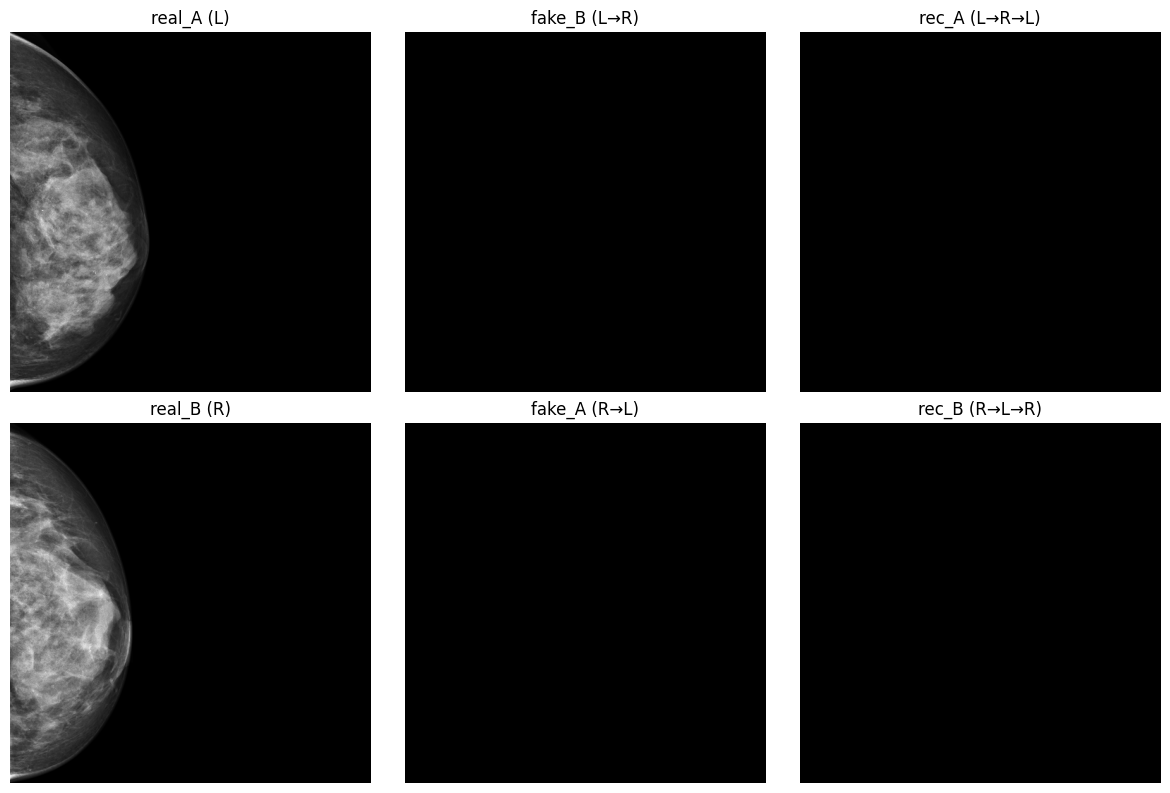

ResnetGenerator(
  (encoder): ModuleList(
    (0): ReflectionPad2d((3, 3, 3, 3))
    (1): Conv2d(1, 64, kernel_size=(7, 7), stride=(1, 1))
    (2): InstanceNorm2d(64, eps=1e-05, momentum=0.1, affine=False, track_running_stats=False)
    (3): ReLU(inplace=True)
    (4): Conv2d(64, 128, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (5): InstanceNorm2d(128, eps=1e-05, momentum=0.1, affine=False, track_running_stats=False)
    (6): ReLU(inplace=True)
    (7): Conv2d(128, 256, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (8): InstanceNorm2d(256, eps=1e-05, momentum=0.1, affine=False, track_running_stats=False)
    (9): ReLU(inplace=True)
  )
  (bottleneck): Sequential(
    (0): _ResBlock(
      (block): Sequential(
        (0): ReflectionPad2d((1, 1, 1, 1))
        (1): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1))
        (2): InstanceNorm2d(256, eps=1e-05, momentum=0.1, affine=False, track_running_stats=False)
        (3): ReLU(inplace=True)
        (4): Reflectio

In [26]:
import numpy as np
import matplotlib.pyplot as plt

model.G_AB.eval()
model.G_BA.eval()

real_A, real_B = dataset[0]
real_A = real_A.unsqueeze(0).to(device)
real_B = real_B.unsqueeze(0).to(device)

with torch.no_grad():
    fake_B = model.G_AB(real_A)
    fake_A = model.G_BA(real_B)
    rec_A  = model.G_BA(fake_B)
    rec_B  = model.G_AB(fake_A)

def _to_img(t):
    return ((t.squeeze().cpu().numpy() + 1) * 127.5).clip(0, 255).astype(np.uint8)

titles = ["real_A (L)", "fake_B (L→R)", "rec_A (L→R→L)",
          "real_B (R)", "fake_A (R→L)", "rec_B (R→L→R)"]
imgs   = [real_A, fake_B, rec_A, real_B, fake_A, rec_B]

fig, axes = plt.subplots(2, 3, figsize=(12, 8))
for ax, img, title in zip(axes.flat, imgs, titles):
    ax.imshow(_to_img(img), cmap="gray")
    ax.set_title(title)
    ax.axis("off")
plt.tight_layout()
# plt.savefig(os.path.join("../data/output", "sample_translations.png"), dpi=150)
plt.show()

model.G_AB.train()
model.G_BA.train()